In [6]:
import kagglehub
import pandas as pd
import numpy as np
import os

try:
    path = kagglehub.dataset_download("chethuhn/network-intrusion-dataset")
    data = pd.read_csv(os.path.join(path, 'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'))
    print(" Path to dataset files:", path)
    
except Exception as e:
    print(f"Something failed... {e}")

data.head()

 Path to dataset files: /Users/antoniogonzalez/.cache/kagglehub/datasets/chethuhn/network-intrusion-dataset/versions/1


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [7]:
from sklearn.preprocessing import LabelEncoder

data.columns = data.columns.str.strip()

le = LabelEncoder()

columns_drop = [
    'Fwd Header Length.1',
    'Avg Fwd Segment Size',
    'Subflow fwd bytes',
    'Subflow fwd packets',
    'Subflow bwd Packets',
    'Subflow bwd bytes',
    'Packet Length Variance' 
]


data['Label'] = le.fit_transform(data['Label'])

data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.dropna(inplace=True)

data = data.drop(columns=columns_drop, errors='ignore')

X = data.drop('Label', axis=1)
y = data['Label']

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=1)

In [9]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx] 

    xgb = XGBClassifier(eval_metric='mlogloss', random_state=1)
    xgb.fit(X_train, y_train)


    y_pred = xgb.predict(X_test)
    print('-Fold--')
    print(classification_report(y_test, y_pred))

-Fold--
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19538
           1       1.00      1.00      1.00     25605

    accuracy                           1.00     45143
   macro avg       1.00      1.00      1.00     45143
weighted avg       1.00      1.00      1.00     45143

-Fold--
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19537
           1       1.00      1.00      1.00     25605

    accuracy                           1.00     45142
   macro avg       1.00      1.00      1.00     45142
weighted avg       1.00      1.00      1.00     45142

-Fold--
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19537
           1       1.00      1.00      1.00     25605

    accuracy                           1.00     45142
   macro avg       1.00      1.00      1.00     45142
weighted avg       1.00      1.00      1.00     45

2
1.0000001
[7.6018722e-04 7.7330944e-05 2.1080630e-05 3.1475902e-06 3.1651688e-01
 0.0000000e+00 2.3227574e-03 0.0000000e+00 6.6444200e-01 7.7521842e-04
 0.0000000e+00 0.0000000e+00 3.3387579e-03 3.7908697e-04 2.6527179e-05
 2.1482083e-05 1.4547238e-04 1.2827489e-04 2.4060768e-05 7.5904405e-05
 7.3568219e-05 5.3005619e-04 2.3747768e-04 4.3831009e-05 6.5795895e-05
 5.8974803e-04 2.5595475e-05 1.2721830e-05 3.7738318e-05 2.9199387e-05
 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 4.1315638e-04
 3.2111199e-03 1.2214200e-05 4.2372802e-04 0.0000000e+00 0.0000000e+00
 1.0891419e-04 7.9884479e-04 8.9255837e-04 0.0000000e+00 0.0000000e+00
 0.0000000e+00 4.2022046e-04 1.7614474e-03 0.0000000e+00 0.0000000e+00
 8.4122257e-06 5.8176123e-05 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00 0.0000000e+00 0.0000000e+00 3.5699582e-04 2.7354583e-04
 1.6454168e-04 0.0000000e+00 2.7140331e-05 0.0000000e+00 4.009863

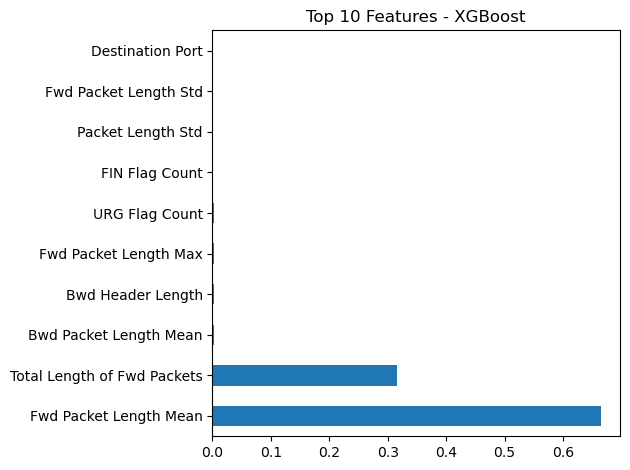

In [10]:
import matplotlib.pyplot as plt

xgb_importance = XGBClassifier(eval_metric='mlogloss', random_state=1)
xgb_importance.fit(X,y)


print(xgb_importance.n_classes_)
print(xgb_importance.feature_importances_.sum())
print(xgb_importance.feature_importances_)

importance = pd.Series(xgb_importance.feature_importances_, index=X.columns)
print(importance.nlargest(10))

importance.nlargest(10).plot(kind='barh')
plt.title('Top 10 Features - XGBoost')
plt.tight_layout()
plt.show()